# Week 2 Lab — SOLUTIONS — The Classical Linear Regression Model I

**MANG2074 Financial Econometrics 1**

**Objectives**

- Estimate simple OLS regressions with `statsmodels`.
- Compute the optimal hedge ratio in levels and in returns, and understand why the returns regression is the valid one.
- Test hypotheses about individual coefficients, including $H_0:\beta=1$.
- Estimate and interpret a CAPM beta and alpha.

**Data**

- `../data/sandphedge.csv` — monthly S&P 500 `Spot` and `Futures` prices, 1997–2018.
- `../data/capm.csv` — monthly prices for `SANDP`, `FORD`, `GE`, `MICROSOFT`, `ORACLE` plus the annualised 3-month T-bill rate `USTB3M`, 2002–2018.


## Task 1 — Load the hedging data and construct returns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

hedge = pd.read_csv('../data/sandphedge.csv', index_col=0, parse_dates=True)

# Percentage log returns: r_t = 100 * (ln P_t - ln P_{t-1})
hedge['rspot'] = 100 * np.log(hedge['Spot']).diff()
hedge['rfutures'] = 100 * np.log(hedge['Futures']).diff()

print(hedge[['rspot', 'rfutures']].describe())


            rspot    rfutures
count  246.000000  246.000000
mean     0.416776    0.414017
std      4.333323    4.419049
min    -18.563647  -18.944697
25%     -1.831388   -1.931400
50%      0.918522    0.997641
75%      3.276468    3.133588
max     10.230659   10.387184


**What to interpret.** Spot and futures returns have nearly identical means (~0.4% per month) and standard deviations (~4.3–4.4%) — unsurprising, since index futures are priced off the spot by cost-of-carry arbitrage. The futures return is marginally more volatile, which is typical.

## Task 2 — Hedge ratio regression in LEVELS

In [2]:
levels_res = smf.ols('Spot ~ Futures', data=hedge).fit()
print(levels_res.summary())


                            OLS Regression Results                            
Dep. Variable:                   Spot   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.005e+06
Date:                Thu, 11 Jun 2026   Prob (F-statistic):               0.00
Time:                        01:10:21   Log-Likelihood:                -826.86
No. Observations:                 247   AIC:                             1658.
Df Residuals:                     245   BIC:                             1665.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.8378      1.489     -1.906      0.0

**What to interpret.** $R^2 \approx 1.00$ and a slope t-ratio in the hundreds. This is **not** evidence of a great model: both prices share a common stochastic trend, so the regression mostly fits trend on trend. With non-stationary variables the usual t and F distributions do not apply, and regressions like this can be *spurious*. The slope (~1.0) is not a usable hedge ratio for managing month-to-month risk — risk lives in *changes*, not levels.

## Task 3 — Hedge ratio regression in RETURNS

In [3]:
rets = hedge.dropna()
returns_res = smf.ols('rspot ~ rfutures', data=rets).fit()
print(returns_res.summary())


                            OLS Regression Results                            
Dep. Variable:                  rspot   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 2.147e+04
Date:                Thu, 11 Jun 2026   Prob (F-statistic):          7.54e-240
Time:                        01:10:21   Log-Likelihood:                -157.16
No. Observations:                 246   AIC:                             318.3
Df Residuals:                     244   BIC:                             325.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0131      0.029      0.444      0.6

**What to interpret.** The slope — the **optimal hedge ratio** $h^*$ — is about 0.98: to minimise variance, sell roughly 0.98 units of futures per unit of spot exposure. $R^2 \approx 0.99$ here is legitimate (both series are stationary returns and genuinely move together one-for-one through arbitrage). The intercept is economically negligible.

## Task 4 — Test H0: hedge ratio = 1

In [4]:
# statsmodels does the (beta-1)/SE calculation for us:
print(returns_res.t_test('rfutures = 1'))

# By hand:
b = returns_res.params['rfutures']
se = returns_res.bse['rfutures']
t_stat = (b - 1) / se
print(f"\nhand calculation: t = ({b:.4f} - 1)/{se:.4f} = {t_stat:.3f}")
print(f"degrees of freedom = {int(returns_res.df_resid)}")


                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.9751      0.007     -3.746      0.000       0.962       0.988

hand calculation: t = (0.9751 - 1)/0.0067 = -3.746
degrees of freedom = 244


**What to interpret.** $H_0: \beta = 1$ (naive one-for-one hedge is optimal). The t-ratio is about $-3.5$ with a p-value well below 0.05, so we **reject** the naive hedge: the optimal ratio is statistically below 1, albeit only slightly in economic terms (0.98 vs 1). Note the contrast with the printed summary t-stat (~150), which tests the irrelevant hypothesis $\beta=0$.

## Task 5 — Load the CAPM data and build excess returns

In [5]:
capm = pd.read_csv('../data/capm.csv', index_col=0, parse_dates=True)

capm['rford'] = 100 * np.log(capm['FORD']).diff()
capm['rsandp'] = 100 * np.log(capm['SANDP']).diff()

# USTB3M is an ANNUALISED % rate -> divide by 12 for a monthly rate
capm['erford'] = capm['rford'] - capm['USTB3M'] / 12
capm['ersandp'] = capm['rsandp'] - capm['USTB3M'] / 12

df = capm.dropna()
print(df[['erford', 'ersandp']].describe())


           erford     ersandp
count  193.000000  193.000000
mean    -0.292935    0.350865
std     13.451561    4.134660
min    -86.533208  -18.441472
25%     -6.239714   -1.728587
50%     -1.061981    0.949000
75%      4.493180    2.709558
max     82.130339   10.063874


**What to interpret.** Ford’s monthly excess return averages close to zero but with a huge standard deviation (~13% per month — the sample includes Ford’s 2008–09 near-death experience), versus ~4% for the market. High total volatility, however, does not by itself mean high *systematic* risk — that is what beta measures.

## Task 6 — Estimate the CAPM regression for Ford

In [6]:
capm_res = smf.ols('erford ~ ersandp', data=df).fit()
print(capm_res.summary())


                            OLS Regression Results                            
Dep. Variable:                 erford   R-squared:                       0.337
Model:                            OLS   Adj. R-squared:                  0.334
Method:                 Least Squares   F-statistic:                     97.26
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           8.36e-19
Time:                        01:10:21   Log-Likelihood:                -735.26
No. Observations:                 193   AIC:                             1475.
Df Residuals:                     191   BIC:                             1481.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9560      0.793     -1.205      0.2

**What to interpret.** $\hat\beta \approx 1.9$: Ford is an *aggressive* stock — when the market’s excess return moves by 1 percentage point, Ford’s moves by about 1.9 points on average. This is plausible for a cyclical, highly levered carmaker. $R^2 \approx 0.33$: about a third of Ford’s return variation is market-related; the rest is idiosyncratic (diversifiable). $\hat\alpha \approx -0.96\%$ per month but with a large standard error.

## Task 7 — Hypothesis tests on beta and alpha

In [7]:
# (a) beta = 0: read from the summary
print(f"(a) H0: beta=0   t = {capm_res.tvalues['ersandp']:.3f}, p = {capm_res.pvalues['ersandp']:.4g}  -> reject")

# (b) beta = 1
print("\n(b) H0: beta=1")
print(capm_res.t_test('ersandp = 1'))

# (c) alpha = 0: read from the summary
print(f"(c) H0: alpha=0  t = {capm_res.tvalues['Intercept']:.3f}, p = {capm_res.pvalues['Intercept']:.4f}")


(a) H0: beta=0   t = 9.862, p = 8.355e-19  -> reject

(b) H0: beta=1
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             1.8898      0.192      4.643      0.000       1.512       2.268
(c) H0: alpha=0  t = -1.205, p = 0.2295


**What to interpret.** (a) Beta is overwhelmingly significant — Ford definitely carries market risk. (b) $H_0:\beta=1$ is also rejected: Ford is significantly *more* sensitive than the market. (c) $H_0:\alpha=0$ is **not** rejected at 5% — consistent with the CAPM: after accounting for market risk, Ford earned no significant abnormal return. A significantly positive alpha would have indicated returns above the CAPM-required compensation, i.e. apparent mispricing (or a missing risk factor).

## Task 8 — Scatter plot with the fitted line

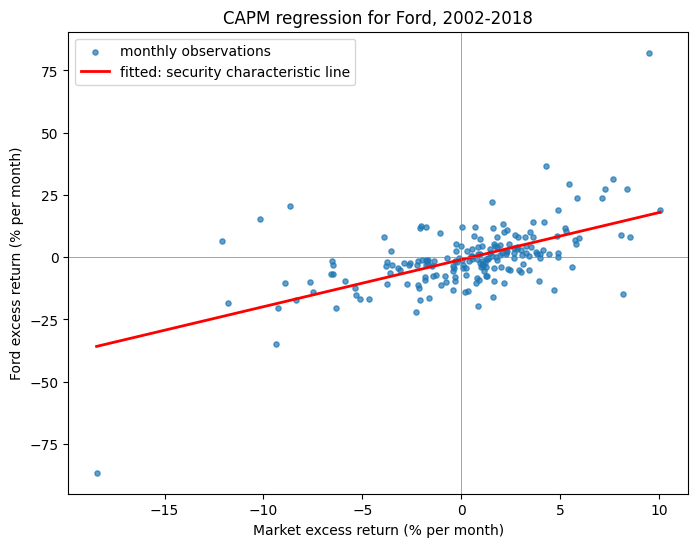

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(df['ersandp'], df['erford'], s=14, alpha=0.7, label='monthly observations')
xs = np.linspace(df['ersandp'].min(), df['ersandp'].max(), 100)
plt.plot(xs, capm_res.params['Intercept'] + capm_res.params['ersandp'] * xs,
         'r-', lw=2, label='fitted: security characteristic line')
plt.axhline(0, color='grey', lw=0.5); plt.axvline(0, color='grey', lw=0.5)
plt.xlabel('Market excess return (% per month)')
plt.ylabel('Ford excess return (% per month)')
plt.title('CAPM regression for Ford, 2002-2018')
plt.legend()
plt.show()


**What to interpret.** The cloud slopes up steeply (beta ≈ 1.9) but is wide — the large vertical scatter around the line is Ford’s idiosyncratic risk (the 67% of variance not explained by the market). A few extreme points (2008–09) are influential; Week 4 returns to outliers and structural stability.

## Task 9 — Summary

- **Hedging:** the variance-minimising hedge ratio is ≈0.98 futures per unit of spot. Statistically we reject the naive ratio of 1 (t ≈ −3.5), though economically the difference is small. The levels regression looked "perfect" ($R^2≈1$) but is invalid because prices are non-stationary.
- **CAPM:** Ford’s beta ≈ 1.9 — significantly above both 0 and 1: a high-systematic-risk stock. Its alpha (≈ −1% per month) is statistically indistinguishable from zero, so there is no evidence of abnormal performance relative to the CAPM over 2002–2018.